<a data-flickr-embed="true" href="https://www.flickr.com/photos/hdude/3717789653/in/photolist-6EwDkB-myH9z-awVCS2-ko8WuX-agQBZz-6cB91E-WHkrp-ohN4tu-DiqGJ-4qKQLd-4Je3yy-pR6Txo-8cwXRc-GMxcHq-s6gViv-ec9N1p-36zmK6-5g7Hu-36jjPo-36eEu6-6fcqy8-dfnTGd-51d6zE-36DC4u-36yCTg-ioBwh-4GvtA-CCyeG-4Qicvk-7phH9-UthyPn-bwmSb1-9XwPcV-jdrnsg-7UiPhw-HXFPwG-9xg4sw-s6RwiZ-7GWAAL-8mCcMV-amphd7-6zxH2P-3eqHcu-7ZHseq-9HrvXt-7wesR1-4GwZv-ooku7x-zyAz6N-fUwnQ2" title="Hippocampus"><img src="https://live.staticflickr.com/2673/3717789653_604a89f220_z.jpg" width="640" height="466" alt="Hippocampus"></a><script async src="//embedr.flickr.com/assets/client-code.js" charset="utf-8"></script>

Image credit: ["Hippocampus"](https://flic.kr/p/6EwDkB) by Vic DeLeon, licensed under CC BY-NC-ND 2.0

# **MRI analysis using the MIRIAD dataset**

Created by: Narayan Sankaran, 
NEUR202, University of San Francisco

Adapted from Valerie Carr, SJSU

Purpose: To use Python and Google Colab to perform analyses on the MIRIAD data set

## Introduction: MIRIAD data analyis
Let's use Python to analyze volume measurements based on hippocampal regions of interest (ROIs). The MIRIAD data set includes MRI scans from:
* 23 individuals with Alzheimer's disease
* 23 age-matched healthy controls

For each participant, we have data regarding:
* Their group (AD, Control)
* Their age
* Their gender (male, female)
* Their left hippocampal volume
* Their score on the Mini Mental State Examination (MMSE), a test of global cognition

## Exercise 1: Load relevant libraries
We need to import a few code "libraries" that are specialized for different purposes. Click the play button below.

In [25]:
# Library for working with spreadsheet data
import pandas as pd

# Libraries for stats
from scipy import stats

# Libraries for plotting
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_palette('Set2')

print('imported libraries')

imported libraries


## Exercise 2: Load data
Next, we need to tell Python where to find the spreadsheet that contains our data, and let's load the file and check to make sure that it looks right by viewing the first 20 rows. 


In [26]:
file = 'miriad_analysis.csv'
miriad = pd.read_csv(file)
miriad

,student,id,group,age,gender,mmse,hipp_volume
0,Niyathi,miriad_190,AD,85.85,male,20,441
1,Niyathi,miriad_191,AD,79.90,female,23,769
2,Gabrielle,miriad_193,AD,66.79,male,25,1391
3,Gabrielle,miriad_194,AD,62.43,female,14,955
4,Niyathi,miriad_197,Control,65.88,female,29,1974
5,Sally,miriad_198,AD,70.54,female,19,916
6,Gabrielle,miriad_199,Control,68.12,female,30,794
7,Gaurav,miriad_200,Control,68.75,male,29,1772
8,Niyathi,miriad_202,Control,67.85,male,30,1299
9,Sally,miriad_204,AD,65.75,male,19,1151


## Exercise 3: Descriptive statistics for each variable


Let's start by getting a feel for our data set. We have three different continuous variables in our data: 
* Age
* MMSE score
* Hippocampal volume

Below, you'll find several code cells to explore these descriptive statistics. From here on out, you can assume that in order to see the results, you'll need to click the play button for each cell.



In [27]:
miriad.describe()

,age,mmse,hipp_volume
count,46.000000,46.000000,46.000000
mean,69.546739,24.391304,1566.804348
std,7.646011,5.934750,575.408748
min,55.650000,10.000000,441.000000
25%,65.015000,19.250000,1151.500000
50%,68.515000,26.000000,1585.000000
75%,73.855000,30.000000,1996.500000
max,85.850000,30.000000,2684.000000


The stats above describe the entire data set, but what we really want is to break things down by group (AD vs. controls). The code below will provide descriptive stats for age, MMSE, and hippocampal volume for each group.

In [28]:
miriad.groupby('group').describe()

age                                                            mmse  \
        count       mean       std    min     25%    50%     75%    max count   
group                                                                           
AD       23.0  69.430870  8.249065  55.65  64.340  68.56  74.385  85.85  23.0   
Control  23.0  69.662609  7.176710  58.05  65.325  68.47  72.800  85.74  23.0   

                    ...             hipp_volume                           \
              mean  ...   75%   max       count         mean         std   
group               ...                                                    
AD       19.304348  ...  23.0  25.0        23.0  1448.608696  624.795511   
Control  29.478261  ...  30.0  30.0        23.0  1685.000000  507.602565   

                                                
           min     25%     50%     75%     max  
group                                           
AD       441.0   993.5  1391.0  1945.5  2684.0  
Control  794.0  1324.5  1691.0  2043.5  2601.0  

[2 rows x 24 columns]

#### Discussion prompt 1:
* Do the groups (AD, control) seem well-matched in terms of age?
* Keeping in mind that all we are doing right now is eyeballing numerical differences (i.e., we haven't performed any statistical tests yet):
    * Do you think there is a difference in average MMSE score between AD and controls? 
    * Do you think there is a difference in average hippocampal volume between AD and controls?

If we wanted to, we could also look at descriptive stats broken down by group *and* gender:

In [ ]:
miriad.groupby(['group','gender']).describe()

## Exercise 4: Differences in MMSE scores (AD vs. control)

### 4a. Plotting the data
* The maximum  MMSE score (indicating perfect performance) is 30 points.
* A score of 25 to 27 is in the low range of normal and indicates that follow-up testing may be needed.
* A score of 20 to 24 suggests mild dementia
* 13 to 20 suggests moderate dementia
* Less than 12 indicates severe dementia.

Let's begin by creating a plot to look at the distribution of MMSE scores for our two groups using a box plot with individual data points overlaid. If you're not familiar with box plots, [this page](https://en.wikipedia.org/wiki/Box_plot#Elements_of_a_box_plot) on Wikipedia is useful. 

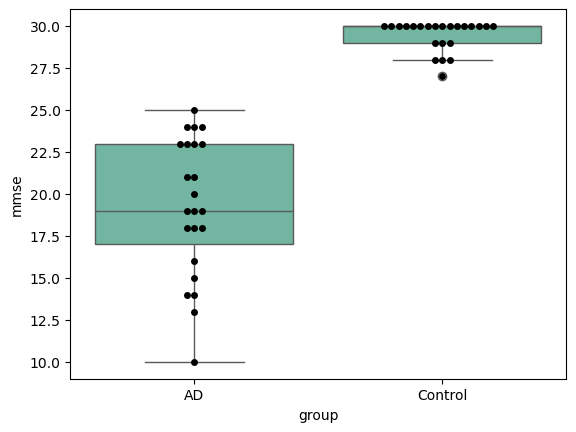

In [29]:
mmse_group_box = sns.boxplot(x = 'group', y = 'mmse', data = miriad)
mmse_group_swarm = sns.swarmplot(x = 'group', y = 'mmse', color = 'black', data = miriad)
plt.show()

### 4b. Statistical testing (independent samples t-test)
Given that the variances of our two groups are very different, we can't perform a student's independent samples t-test (the typical kind). Instead, we'll perform a variant called the Welch's t-test, designed for samples with unequal variance.

* The first number in the output is the t-statistic. A negative value means that the group listed first (AD) has a lower score than the group listed second.
* The second number in the output is the p-value. Think back to your stats class – how small does the p-value need to be in order to be considered significant?
    * Note: the p-value is written in scientific notation. If you need help understanding this notation (which is perfectly reasonable!), ask for help.

In [30]:
# Welch's independent samples t-test (for unequal variance)
stats.ttest_ind(miriad.mmse[miriad.group == 'AD'], 
                miriad.mmse[miriad.group == 'Control'], equal_var = False)

TtestResult(statistic=-11.520728822251534, pvalue=2.7918098048555308e-11, df=24.06648757312815)

#### Discussion prompt 2
* What do you notice about the control data? Is there much variability in how they're performing compared with AD?
* Would you say that most of the AD group's scores suggest mild, moderate, or severe dementia?
* Is the group difference in MMSE scores significant? If so, which group has higher scores? Is this the result you expected?

## Exercise 5. Differences in Hippocampal volumes (AD vs. control)

### 5a. Plotting the data
For hippocampal volume, let's begin by taking a look at how these values are distributed within each group:

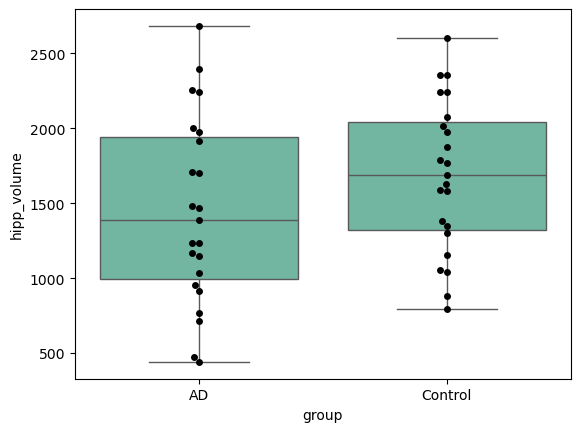

In [31]:
hipp_group_box = sns.boxplot(x = 'group', y = 'hipp_volume', data = miriad)
hipp_group_swarm = sns.swarmplot(x = 'group', y = 'hipp_volume', 
                                 color = 'black', data = miriad)
plt.show()

### 5b. Statistical testing (independent samples t-test)
Given that the variances of our two groups are more similar this time, we can use a student's independent samples t-test.
* Like last time, the first number in the output is the t-statistic. A negative value means that the group listed first (AD) has a lower volume than the group listed second (control).
* The second number in the output is the p-value. Check to see whether it's significant.

In [32]:
# Student's independent samples t-test (for equal variance)
stats.ttest_ind(miriad.hipp_volume[miriad.group == 'AD'],
                miriad.hipp_volume[miriad.group == 'Control'], 
                nan_policy = 'omit')

TtestResult(statistic=-1.408308913529806, pvalue=0.16606668616528197, df=44.0)

#### Discussion prompt 3
* Is the group difference in hippocampal volumes significant? Is this the result you expected?

## Exercise 6: Correlations between age and hippocampal volume
Perhaps the effects of Alzheimer's Disease are more nuanced! For our next set of analyses, we'll examine correlations between some of our continuous measures (age, MMSE score, and hippocampal volumes) and see whether the relationships between these continuous variables differ based on group (AD vs. control). For each pair of measurements, we'll create a scatter plot and conduct a correlational analysis (Pearson's r). 

With respect to the scatter plots:
* If you see an upward line, that suggests we may have a positive correlation between each measure
* If you see a downward line, that suggests we may have a negative correlation between each measure
* If you see a rather flat line, that suggests that there is not a significant correlation between measures

Let's begin with examining the correlation between Age and Hippocampal volume.

### 6a. Plotting the data
Below, you'll create a scatter plot with age on the x-axis and hippocampal volume on the y-axis:

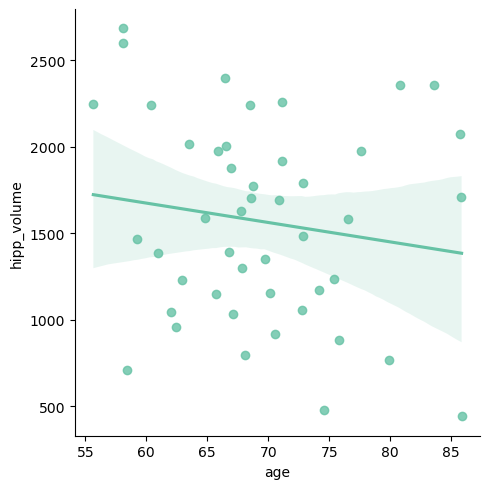

In [33]:
age_hipp_all = sns.lmplot(x = 'age', y = 'hipp_volume', data = miriad)
plt.show()

### 6b. Statistical testing
Let's find out if you were right! Run the cell below, which will produce two numbers:
* The first number is the *r value*, which can range from -1 to 1. A negative value indicates a negative relationship, and a positive value indicates a positive relationship. A value near zero indicates very little relationship.
* The second number is the *p-value* – check whether it's significant using an alpha-level = 0.05.


In [34]:
miriad_dropna = miriad.dropna()
stats.pearsonr(miriad_dropna.age, miriad_dropna.hipp_volume)

PearsonRResult(statistic=-0.14899921445373418, pvalue=0.3230148413655092)

### 6c. Separate scatterplots by group (AD vs. control)
Rather than look at the correlation between age and MMSE score for the entire sample, we can instead look at this correlation for each (AD, control) separately. Below, you'll create a scatter plot that shows each group separately:

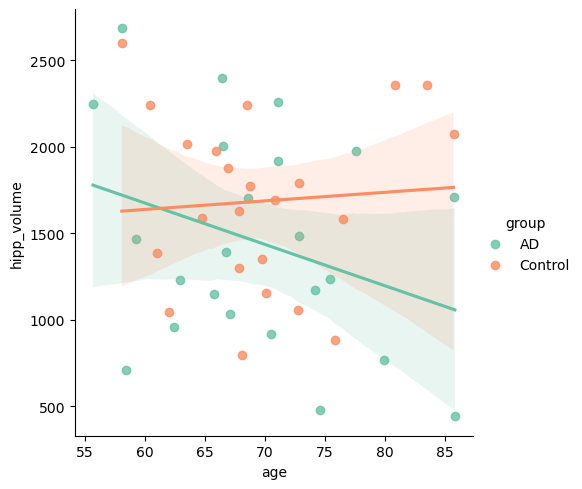

In [35]:
age_hipp_group = sns.lmplot(x = 'age', y = 'hipp_volume', hue = 'group', 
                            data = miriad)
plt.show()

### 6d. Testing each group separately
You know the drill! Below, you'll conduct correlational analyses separately for each group. The first value is r, the second value is p.

In [36]:
# AD group
miriad_dropna_ad = miriad_dropna[miriad_dropna.group == 'AD']
stats.pearsonr(miriad_dropna_ad.age, miriad_dropna_ad.hipp_volume)

PearsonRResult(statistic=-0.3152298275631608, pvalue=0.14288273371354593)

In [37]:
# Control group
miriad_dropna_con = miriad_dropna[miriad_dropna.group == 'Control']
stats.pearsonr(miriad_dropna_con.age, miriad_dropna_con.hipp_volume)

PearsonRResult(statistic=0.07005014445868615, pvalue=0.7507850458979938)

#### Discussion prompt 4:
* Does the relationship between age and hippocampal volume seem different for the two groups?
* What direction is the relationship, if any (positive or negative)?
* Were either of the correlations significant? 

## Exercise 7. Hippocampal volume and MMSE
Maybe hippocampal volume varies with MMSE score rather than age. For our final round of correlational analyses, we'll look at the relationship between hippocampal volume and MMSE score. Like before, we'll start with the whole sample, and then we'll break things down by group.

### 7a. Plotting the data
Below, let's create a scatter plot for the whole sample, with hippocampal volume on the x-axis, and MMSE score on the y-axis:

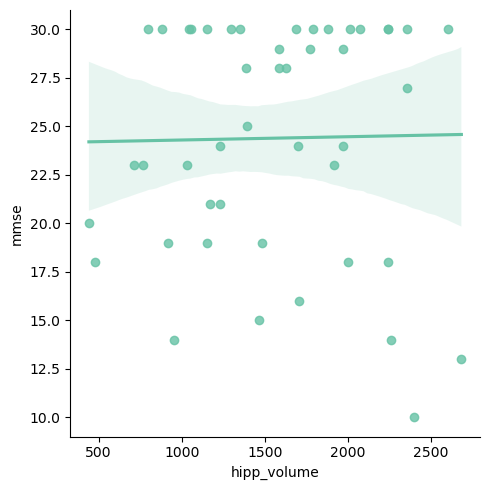

In [38]:
hipp_mmse_all = sns.lmplot(x = 'hipp_volume', y = 'mmse', data = miriad)
plt.show()

#### Discussion prompt:
* Does there appear to be a correlation between hippocampal volume and MMSE score? If so, in which direction?

### 7b. Statistical testing
Let's find out if you were right! As usual, the first value is r, and the second value is p.

In [39]:
stats.pearsonr(miriad_dropna.hipp_volume, miriad_dropna.mmse)

PearsonRResult(statistic=0.01640208482701446, pvalue=0.913844943706517)

### 7c. Separate scatterplots by group (AD vs. control)
Next, let's recreate the scatter plot, but this time with the groups separated:

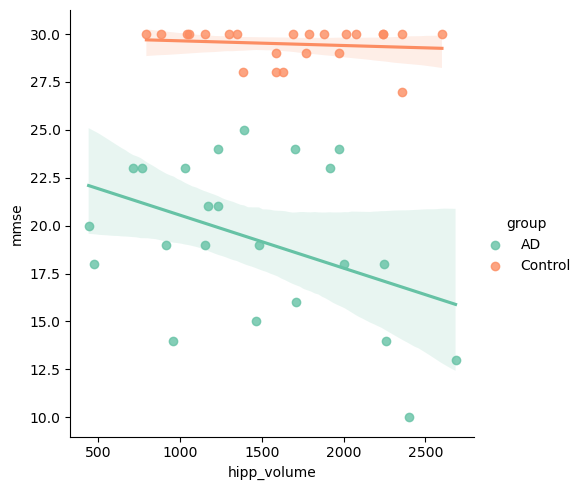

In [40]:
age_hipp_group = sns.lmplot(x = 'hipp_volume', y = 'mmse', hue = 'group', 
                            data = miriad)
plt.show()

### 7d. Testing each group
Last set of tests! Did you guess correctly? As usual, the first value is r, and the second value is p.

In [41]:
# AD group
miriad_dropna_ad = miriad_dropna[miriad_dropna.group == 'AD']
stats.pearsonr(miriad_dropna_ad.hipp_volume, miriad_dropna_ad.mmse)

PearsonRResult(statistic=-0.41746840224634996, pvalue=0.04747628627546654)

In [42]:
# Control group
miriad_dropna_con = miriad_dropna[miriad_dropna.group == 'Control']
stats.pearsonr(miriad_dropna_con.hipp_volume, miriad_dropna_con.mmse)

PearsonRResult(statistic=-0.1383168689798552, pvalue=0.529094539501754)

#### Discussion prompt 5:
* Does the relationship between hippocampal volume and MMSE score seem different for the two groups?
* What is the direction of the relationship, if any? (positive or negative)
* Was either correlation significant? 

### Exercise 8: Conclusions
Now that you've run a LOT of analyses, what conclusions can you draw about the results? In your answer, consider the following:
* Was our hypothesis supported, i.e., that hippocampal volumes will be smaller in the AD group than the control group? 
* Did the additional analyses involving age and MMSE turn up anything interesting that can help us understand how aging, Alzheimer's disease, and gender relate to hippocampal volume and cognitive abilities? 